### Code for example 1
#### demonstrate two estimations of $P_0$, i.e., $P_1$ and $P_2$ that have the same KL-div with $P_0$ can lead to different decisions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

In [2]:
c1 = "#000091"
c2 = "#E1000F"

In [3]:
xi = np.arange(1, 31)
def pmf(mu, sigma):
    a = -0.5 * ((xi - mu) / sigma) ** 2
    p = np.exp(a - a.max())
    return p / p.sum()

def kl(p, q):
    return np.sum(p * (np.log(p) - np.log(q)))

P_0 = pmf(17.0, 3.0)
P_1 = pmf(17.6, 2.8)
delta = kl(P_0, P_1)

low, high = 2.0, 17.0
for _ in range(80):
    mid = (low + high) / 2
    if kl(P_0, pmf(mid, 3.0)) > delta:
        low = mid
    else:
        high = mid
P_2 = pmf((low + high) / 2, 3.0)

Z_all = np.array([
    (zo, zd, zr)
    for zr in range(3, 31, 3)
    for zo in range(zr + 1)
    for zd in range(zr + 1)
])
zo, zd, zr = [Z_all[:, j, None] for j in range(3)]
C = np.zeros((len(Z_all), len(xi)))
for tau in range(3, 8):
    T = np.maximum(zr, zo + tau)
    C += (
        np.maximum(zr - zo - tau, 0)
        + 5 * (
            np.maximum(xi - zd, 0)
            + np.maximum(T - np.maximum(xi, zd), 0)
        )
        + 25 * np.maximum(T - xi, 0) * (xi < zd)
    ) / 5
expected_costs = C @ np.column_stack([P_0, P_1, P_2])
best = np.argmin(expected_costs, axis=0)
Z_0, Z_1, Z_2 = Z_all[best].copy()
regret = expected_costs[best, 0] - expected_costs[best[0], 0]

print("KL(P_0 || P_1):", kl(P_0, P_1))
print("KL(P_0 || P_2):", kl(P_0, P_2))
print("Z_0 =", Z_0)
print("Z_1 =", Z_1)
print("Z_2 =", Z_2)
print("Regret =", regret)

KL(P_0 || P_1): 0.027945570606389046
KL(P_0 || P_2): 0.027945570606389032
Z_0 = [ 8 15 15]
Z_1 = [ 8 15 15]
Z_2 = [ 6 12 12]
Regret = [0.         0.         2.79819091]


In [7]:
P_0.shape

(30,)

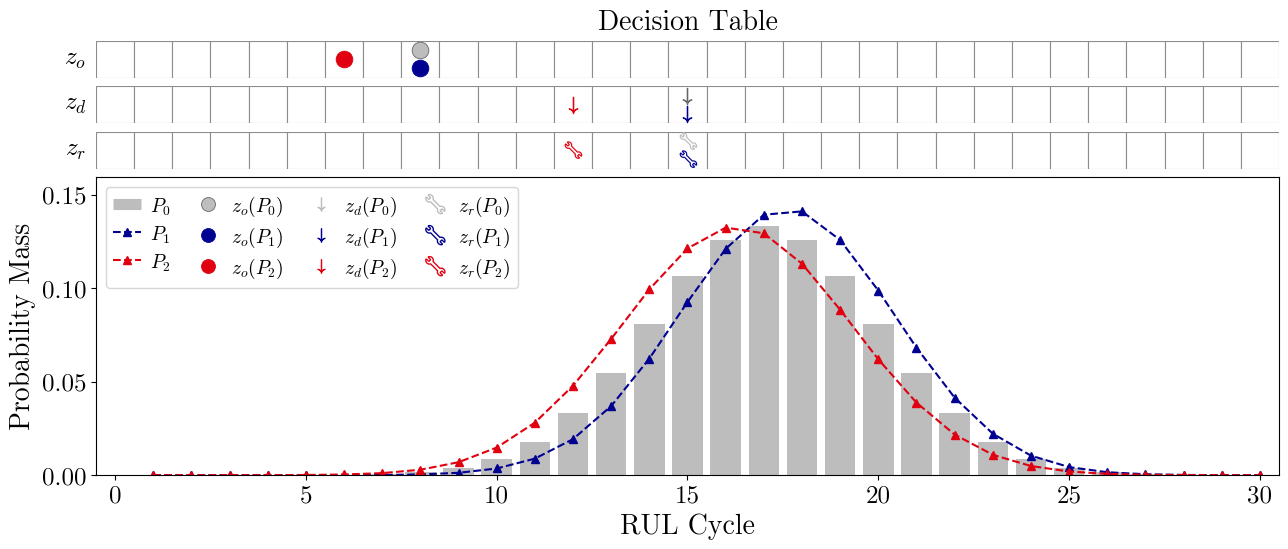

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase
from matplotlib.text import Text

plt.rcParams["font.family"] = ["CMU Serif"]
plt.rcParams["font.size"] = 18
plt.rcParams["mathtext.fontset"] = "cm"


class EmojiHandle:
    def __init__(self, text, color):
        self.text = text
        self.color = color


class HandlerEmoji(HandlerBase):
    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans,
    ):
        artist = Text(
            x=xdescent + width / 2,
            y=(height - ydescent) / 2 + 0.03 * fontsize,
            text=orig_handle.text,
            fontfamily="Segoe UI Emoji",
            fontsize=fontsize,
            color=orig_handle.color,
            ha="center",
            va="center",
            transform=trans,
        )
        return [artist]


H = len(P_0)
xi = np.arange(1, H + 1)

decisions = np.vstack([Z_0, Z_1, Z_2])

colors = [
    "#BDBDBD",
    "#000091",
    "#E1000F",
]

fig, axes = plt.subplots(
    4,
    1,
    sharex=True,
    figsize=(13, 5.5),
    gridspec_kw={
        "height_ratios": [0.5, 0.5, 0.5, 4],
        "hspace": 0.08,
    },
)

schedule_axes = axes[:3]
ax = axes[3]

bars = ax.bar(
    xi,
    P_0,
    width=0.8,
    color=colors[0],
    label=r"$P_0$",
)

line1, = ax.plot(
    xi,
    P_1,
    "^--",
    color=colors[1],
    ms=6,
    label=r"$P_1$",
    zorder=2,
)

line2, = ax.plot(
    xi,
    P_2,
    "^--",
    color=colors[2],
    ms=6,
    label=r"$P_2$",
    zorder=2,
)

ax.set_xlim(-0.5, H + 0.5)

ax.set_ylim(
    0,
    1.13 * max(
        P_0.max(),
        P_1.max(),
        P_2.max(),
    ),
)

ax.set_xticks(
    np.arange(
        0,
        H + 1,
        5,
    )
)

ax.set_xlabel(
    "RUL Cycle",
    fontsize=20,
)

ax.set_ylabel(
    "Probability Mass",
    fontsize=20,
)

ax.set_yticks(
    [0, 0.05, 0.10, 0.15],
    ["0.00", "0.05", "0.10", "0.15"],
)

row_labels = [
    r"$z_o$",
    r"$z_d$",
    r"$z_r$",
]

row_markers = [
    "o",
    r"$\downarrow$",
    None,
]

y_positions = [
    0.74,
    0.26,
    0.50,
]

for j, row_ax in enumerate(schedule_axes):

    for t in range(H + 1):
        row_ax.add_patch(
            Rectangle(
                (t - 0.5, 0),
                1,
                1,
                facecolor="white",
                edgecolor="0.55",
                linewidth=0.8,
            )
        )

    for i in range(3):

        if j < 2:

            row_ax.plot(
                decisions[i, j],
                y_positions[i],
                marker=row_markers[j],
                linestyle="none",
                markersize=12,
                markerfacecolor=colors[i],
                markeredgecolor="0.4" if i == 0 else colors[i],
                markeredgewidth=0.6,
                zorder=3,
            )

        else:

            row_ax.text(
                decisions[i, j],
                y_positions[i],
                "🔧",
                fontfamily="Segoe UI Emoji",
                fontsize=12,
                color=colors[i],
                ha="center",
                va="center",
                zorder=3,
            )

    row_ax.set_ylim(
        0,
        1,
    )

    row_ax.set_yticks([])

    row_ax.set_ylabel(
        row_labels[j],
        rotation=0,
        labelpad=15,
        va="center",
        fontsize=18,
    )

    row_ax.tick_params(
        axis="x",
        which="both",
        bottom=False,
        top=False,
        labelbottom=False,
        labeltop=False,
    )

    for spine in row_ax.spines.values():
        spine.set_visible(False)


schedule_axes[0].set_title(
    "Decision Table",
    fontsize=20,
    pad=8,
)

fig.subplots_adjust(
    left=0.08,
    right=0.99,
    bottom=0.13,
    top=0.92,
)


legend_handles = [
    Line2D(
        [],
        [],
        color=colors[0],
        linewidth=8,
        solid_capstyle="butt",
    ),
    line1,
    line2,
]


for i in range(3):
    legend_handles.append(
        Line2D(
            [],
            [],
            linestyle="none",
            marker="o",
            markersize=10,
            markerfacecolor=colors[i],
            markeredgecolor="0.4" if i == 0 else colors[i],
            markeredgewidth=0.6,
        )
    )


for i in range(3):
    legend_handles.append(
        Line2D(
            [],
            [],
            linestyle="none",
            marker=r"$\downarrow$",
            markersize=10,
            markerfacecolor=colors[i],
            markeredgecolor=colors[i],
            markeredgewidth=0.6,
            color=colors[i],
        )
    )


for i in range(3):
    legend_handles.append(
        EmojiHandle(
            "🔧",
            colors[i],
        )
    )


legend_labels = [
    r"$P_0$",
    r"$P_1$",
    r"$P_2$",
    r"$z_o(P_0)$",
    r"$z_o(P_1)$",
    r"$z_o(P_2)$",
    r"$z_d(P_0)$",
    r"$z_d(P_1)$",
    r"$z_d(P_2)$",
    r"$z_r(P_0)$",
    r"$z_r(P_1)$",
    r"$z_r(P_2)$",
]


leg = ax.legend(
    handles=legend_handles,
    labels=legend_labels,
    handler_map={
        EmojiHandle: HandlerEmoji(),
    },
    ncol=4,
    loc="upper left",
    fontsize=14,
    handleheight=1.0,
    labelspacing=0.35,
    handlelength=1.4,
    handletextpad=0.5,
    columnspacing=1.2,
    frameon=True,
)


plt.savefig(
    "./figs/example1.pdf",
    bbox_inches="tight",
)

plt.show()